<a href="https://colab.research.google.com/github/Dragonfly12347/vpn/blob/main/regressioniot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (123117, 51)
   id.orig_p  id.resp_p proto service  fwd_pkts_tot  bwd_pkts_tot  \
0      38667       1883   tcp    mqtt             9             5   
1      51143       1883   tcp    mqtt             9             5   
2      44761       1883   tcp    mqtt             9             5   
3      60893       1883   tcp    mqtt             9             5   
4      51087       1883   tcp    mqtt             9             5   

   fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  bwd_pkts_per_sec  \
0                  3                  3          0.281148          0.156193   
1                  3                  3          0.282277          0.156821   
2                  3                  3          0.280164          0.155647   
3                  3                  3          0.281593          0.156440   
4                  3                  3          0.282111          0.156728   

   ...  flow_pkts_payload.avg  flow_pkts_payload.std  fwd_iat.min  \
0  ...       

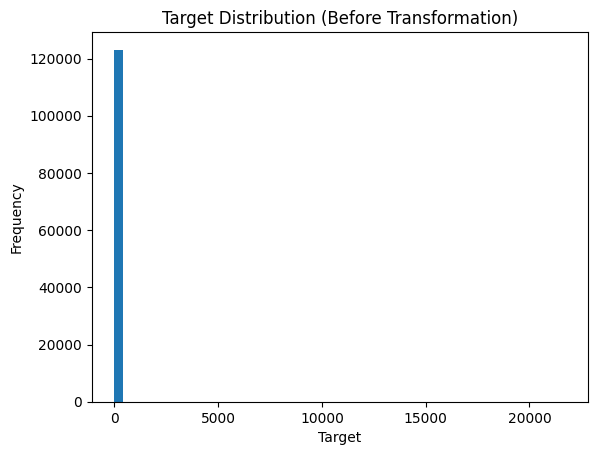

Skewness (Before): 120.9624610892308


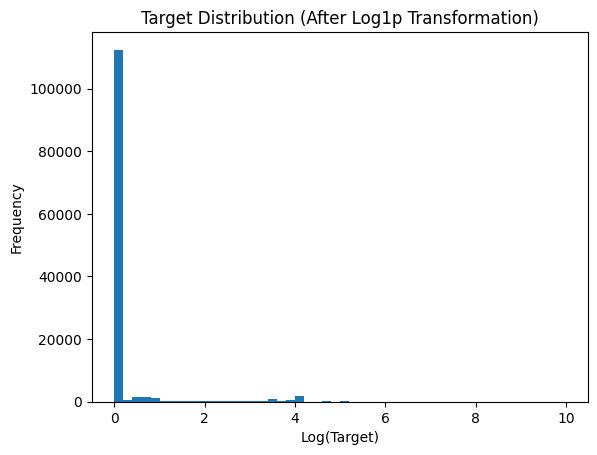

Skewness (After): 4.431628072799557


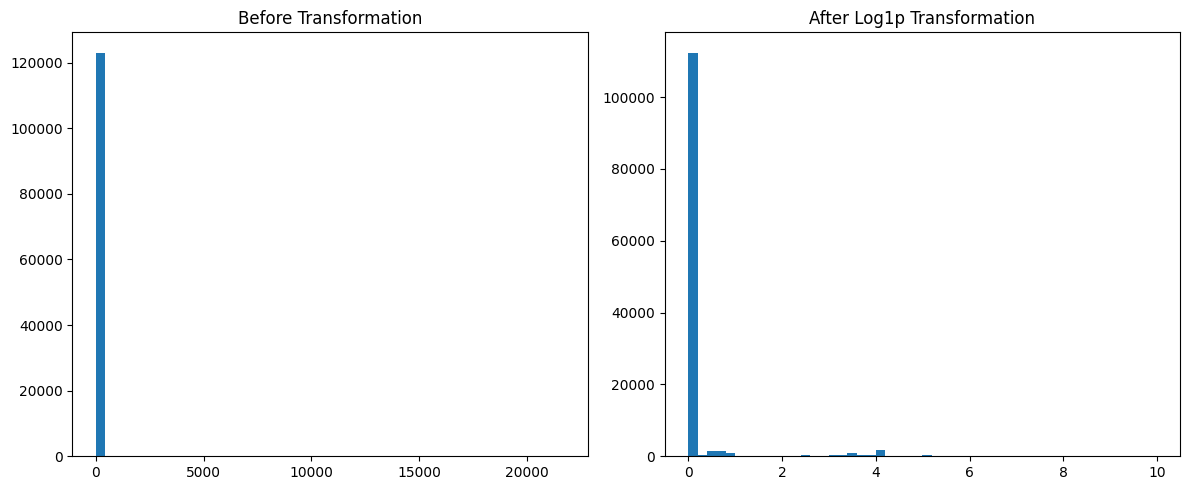


Linear Regression
MAE: 0.14445215719975493
MSE: 21.973062802813608
RMSE: 4.687543365432858
R2: 0.9288048268117672
Time (seconds): 0.11106085777282715


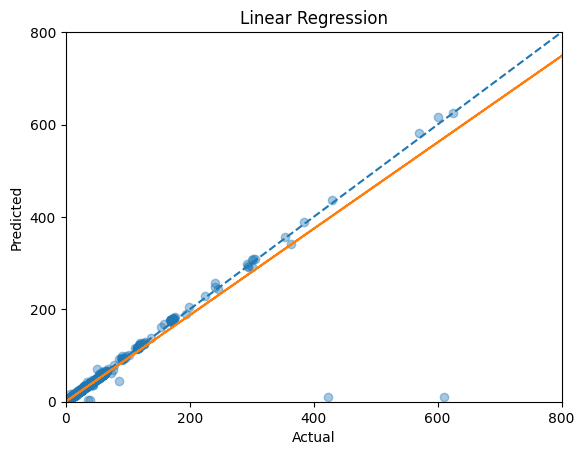


Random Forest
MAE: 0.0273228099096794
MSE: 1.955808196159638
RMSE: 1.398502125904583
R2: 0.993662963397587
Time (seconds): 44.93086004257202


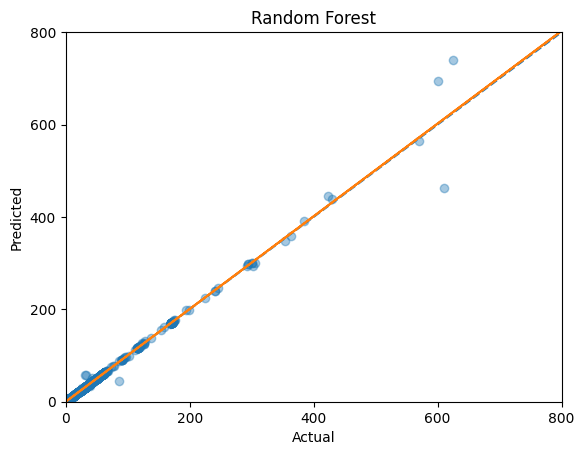

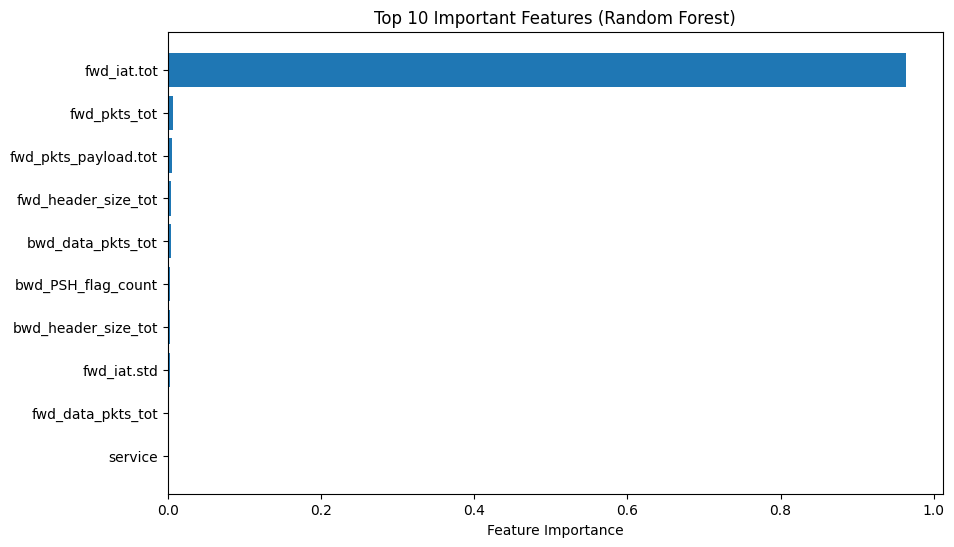


XGBoost
MAE: 0.1476922359486493
MSE: 11.888629901219462
RMSE: 3.4479892548004645
R2: 0.9614795136943886
Time (seconds): 0.6997973918914795


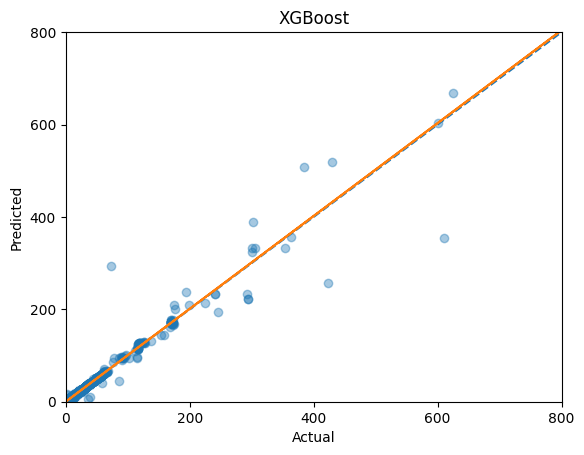

770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

DNN Regressor
MAE: 0.4401897629280124
MSE: 23.00642802394929
RMSE: 4.796501644318418
R2: 0.9254566082886749
Time (seconds): 89.49867510795593


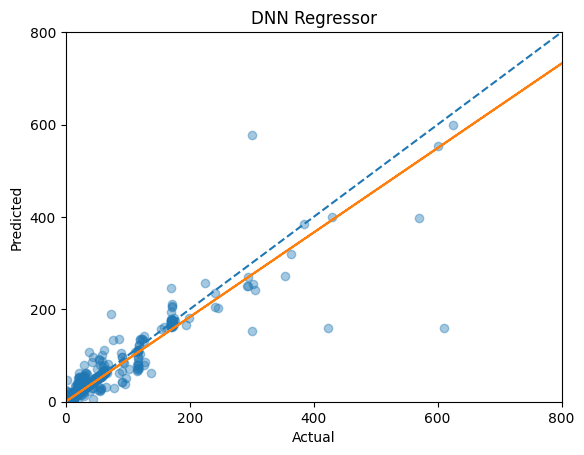

770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Autoencoder Regressor
MAE: 0.5780553580900657
MSE: 51.514032676343945
RMSE: 7.17732768350059
R2: 0.8330887909924434
Time (seconds): 89.61333560943604


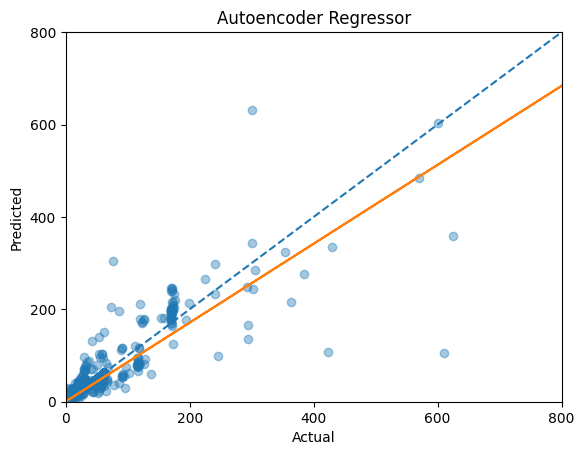


FINAL COMPARISON TABLE
                   Model       MAE        MSE      RMSE        R2   Time (s)
0      Linear Regression  0.144452  21.973063  4.687543  0.928805   0.111061
1          Random Forest  0.027323   1.955808  1.398502  0.993663  44.930860
2                XGBoost  0.147692  11.888630  3.447989  0.961480   0.699797
3          DNN Regressor  0.440190  23.006428  4.796502  0.925457  89.498675
4  Autoencoder Regressor  0.578055  51.514033  7.177328  0.833089  89.613336


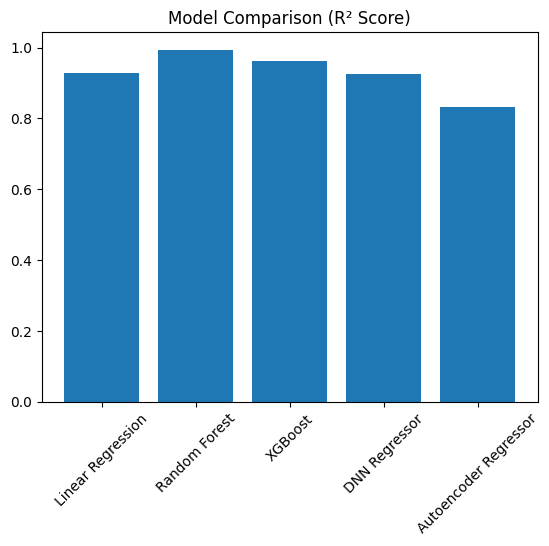

In [ ]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

# =====================================================
# LOAD DATASET
# =====================================================
df = pd.read_csv("rt_iot2022_regression_ready_50_features.csv")
df = df.fillna(0)

print("Dataset shape:", df.shape)
print(df.head())

# =====================================================
# ENCODE CATEGORICAL FEATURES
# =====================================================
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# =====================================================
# DEFINE TARGET
# =====================================================
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]

# =====================================================
# TARGET ANALYSIS
# =====================================================
plt.figure()
plt.hist(y, bins=50)
plt.title("Target Distribution (Before Transformation)")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()

print("Skewness (Before):", y.skew())

y_log = np.log1p(y)

plt.figure()
plt.hist(y_log, bins=50)
plt.title("Target Distribution (After Log1p Transformation)")
plt.xlabel("Log(Target)")
plt.ylabel("Frequency")
plt.show()

print("Skewness (After):", y_log.skew())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(y, bins=50)
plt.title("Before Transformation")

plt.subplot(1,2,2)
plt.hist(y_log, bins=50)
plt.title("After Log1p Transformation")

plt.tight_layout()
plt.show()

# =====================================================
# FEATURE SELECTION
# =====================================================
selector = SelectKBest(score_func=f_regression, k=20)
X_selected = selector.fit_transform(X, y)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# =====================================================
# SCALE FEATURES
# =====================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================================
# PLOT FUNCTION
# =====================================================
def plot_actual_vs_pred(y_test, y_pred, title):
    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.4)

    # Fixed axis range
    plt.xlim(0, 800)
    plt.ylim(0, 800)

    # Fixed ticks
    ticks = [0, 200, 400, 600, 800]
    plt.xticks(ticks)
    plt.yticks(ticks)

    # Perfect prediction line
    plt.plot([0, 800], [0, 800], linestyle='--')

    # Trend line
    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    plt.plot(y_test, p(y_test))

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

# =====================================================
# METRICS FUNCTION
# =====================================================
def evaluate(name, y_test, y_pred, results, elapsed_time):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("Time (seconds):", elapsed_time)

    results.append([name, mae, mse, rmse, r2, elapsed_time])
    plot_actual_vs_pred(y_test, y_pred, name)

results = []

# =====================================================
# LINEAR REGRESSION
# =====================================================
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
end = time.time()
evaluate("Linear Regression", y_test, y_pred_lr, results, end - start)

# =====================================================
# RANDOM FOREST
# =====================================================
start = time.time()
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
end = time.time()
evaluate("Random Forest", y_test, y_pred_rf, results, end - start)

# =====================================================
# TOP 10 IMPORTANT FEATURES (RANDOM FOREST)
# =====================================================
selected_features = X.columns[selector.get_support()]

feature_importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": feature_importances
})

top10 = feature_importance_df.sort_values(
    by="Importance", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

# =====================================================
# XGBOOST
# =====================================================
start = time.time()
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
end = time.time()
evaluate("XGBoost", y_test, y_pred_xgb, results, end - start)

# =====================================================
# DNN REGRESSOR
# =====================================================
start = time.time()
dnn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

dnn.compile(optimizer='adam', loss='mse')
dnn.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

y_pred_dnn = dnn.predict(X_test).flatten()
end = time.time()
evaluate("DNN Regressor", y_test, y_pred_dnn, results, end - start)

# =====================================================
# AUTOENCODER REGRESSOR
# =====================================================
start = time.time()
input_layer = Input(shape=(X_train.shape[1],))

encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(decoded)

output = Dense(1)(decoded)

autoencoder_reg = Model(input_layer, output)
autoencoder_reg.compile(optimizer='adam', loss='mse')

autoencoder_reg.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

y_pred_auto = autoencoder_reg.predict(X_test).flatten()
end = time.time()
evaluate("Autoencoder Regressor", y_test, y_pred_auto, results, end - start)

# =====================================================
# RESULTS TABLE
# =====================================================
results_df = pd.DataFrame(
    results, columns=["Model","MAE","MSE","RMSE","R2","Time (s)"]
)

print("\nFINAL COMPARISON TABLE")
print(results_df)

# =====================================================
# R² BAR GRAPH
# =====================================================
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R² Score)")
plt.show()